Libraries loading

In [1]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


Data Preprocessing

In [3]:
df = pd.read_csv(r"C:\Users\User\Desktop\ML_Project\Data\processed\maharashtra_model_ready.csv")

In [4]:
df.head(20)

,district,year,month,rainfall_mm,SoilMoi_0_10,SoilMoi_10_40,SoilMoi_40_100,SoilMoi_100_200,et_mean_mm,ndvi,...,et_mean_mm_lag1,et_mean_mm_lag2,et_mean_mm_lag3,rainfall_roll3,rainfall_roll6,month_sin,month_cos,target_1m_ahead,target_2m_ahead,target_3m_ahead
0,Ahmednagar,2015,6,127.566858,0.297236,0.297696,0.257036,0.349434,6.980997,0.319885,...,1.985492,1.919723,3.045763,51.386090,27.008090,1.224647e-16,-1.000000e+00,No Drought,No Drought,No Drought
1,Ahmednagar,2015,7,52.172304,0.234076,0.321313,0.282012,0.352772,10.912704,0.362202,...,6.980997,1.985492,1.919723,67.984222,35.689121,-5.000000e-01,-8.660254e-01,No Drought,No Drought,Moderate
2,Ahmednagar,2015,8,65.907127,0.283227,0.327283,0.296945,0.355740,15.930731,0.387364,...,10.912704,6.980997,1.985492,81.882096,46.662365,-8.660254e-01,-5.000000e-01,No Drought,Moderate,Extreme
3,Ahmednagar,2015,9,211.699473,0.343166,0.356753,0.334319,0.365064,15.043684,0.447875,...,15.930731,10.912704,6.980997,109.926301,80.656196,-1.000000e+00,-1.836970e-16,Moderate,Extreme,Extreme
4,Ahmednagar,2015,10,72.067995,0.289113,0.352400,0.357233,0.376176,9.686445,0.481645,...,15.043684,15.930731,10.912704,116.558199,92.271210,-8.660254e-01,5.000000e-01,Extreme,Extreme,Extreme
5,Ahmednagar,2015,11,28.747276,0.231718,0.315782,0.322258,0.364618,7.825525,0.432876,...,9.686445,15.043684,15.930731,104.171582,93.026839,-5.000000e-01,8.660254e-01,Extreme,Extreme,Extreme
6,Ahmednagar,2015,12,0.045454,0.198771,0.288359,0.292413,0.357824,4.214328,0.397299,...,7.825525,9.686445,15.043684,33.620242,71.773272,-2.449294e-16,1.000000e+00,Extreme,Extreme,No Drought
7,Ahmednagar,2016,1,0.004455,0.159775,0.263094,0.267861,0.353344,2.802606,0.340517,...,4.214328,7.825525,9.686445,9.599062,63.078630,5.000000e-01,8.660254e-01,Extreme,No Drought,No Drought
8,Ahmednagar,2016,2,1.242280,0.152059,0.248939,0.253355,0.350385,2.399675,0.300846,...,2.802606,4.214328,7.825525,0.430730,52.301156,8.660254e-01,5.000000e-01,No Drought,No Drought,No Drought
9,Ahmednagar,2016,3,3.732513,0.161982,0.242790,0.246408,0.348261,1.019703,0.272327,...,2.399675,2.802606,4.214328,1.659749,17.639996,1.000000e+00,6.123234e-17,No Drought,No Drought,No Drought


In [5]:
df['district'].unique()

array(['Ahmednagar', 'Akola', 'Amravati', 'Aurangabad', 'Bhandara', 'Bid',
       'Buldana', 'Chandrapur', 'Dhule', 'Garhchiroli', 'Gondiya',
       'Hingoli', 'Jalgaon', 'Jalna', 'Kolhapur', 'Latur', 'Mumbai City',
       'Mumbai Suburban', 'Nagpur', 'Nanded', 'Nandurbar', 'Nashik',
       'Osmanabad', 'Parbhani', 'Pune', 'Raigarh', 'Ratnagiri', 'Sangli',
       'Satara', 'Sindhudurg', 'Solapur', 'Thane', 'Wardha', 'Washim',
       'Yavatmal'], dtype=object)

In [6]:
df = df.drop(df.filter(like="Unnamed:").columns, axis=1)

In [7]:
target_columns = ['target_1m_ahead', 'target_2m_ahead', 'target_3m_ahead']

In [17]:
# 3. Define features and target
features_exclude = ['future_drought_class', 'target_1m_ahead', 'target_2m_ahead', 'target_3m_ahead', 'month', 'district', 'date']
feature_columns = [col for col in df.columns if col not in features_exclude]


In [18]:
X = df[feature_columns]
y = df['target_1m_ahead']

print("Feature names:", feature_columns)
print("Target distribution:\n", y.value_counts())

Feature names: ['year', 'rainfall_mm', 'SoilMoi_0_10', 'SoilMoi_10_40', 'SoilMoi_40_100', 'SoilMoi_100_200', 'et_mean_mm', 'ndvi', 'mean_temp_c', 'ndvi_anomaly', 'SoilMoi_0_10_pct', 'SoilMoi_10_40_pct', 'SoilMoi_40_100_pct', 'SoilMoi_100_200_pct', 'ndvi_roll3', 'SoilMoi_0_10_roll3', 'SoilMoi_10_40_roll3', 'SoilMoi_40_100_roll3', 'SoilMoi_100_200_roll3', 'rainfall_mm_lag1', 'rainfall_mm_lag2', 'rainfall_mm_lag3', 'ndvi_lag1', 'ndvi_lag2', 'ndvi_lag3', 'SoilMoi_0_10_lag1', 'SoilMoi_0_10_lag2', 'SoilMoi_0_10_lag3', 'et_mean_mm_lag1', 'et_mean_mm_lag2', 'et_mean_mm_lag3', 'rainfall_roll3', 'rainfall_roll6', 'month_sin', 'month_cos', 'district_encoded']
Target distribution:
 target_1m_ahead
No Drought    2342
Extreme       1113
Moderate       360
Name: count, dtype: int64


Train_Test_Split(Time Series Data)

In [19]:
train_year = [2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_year = [2022, 2023, 2024]

train_mask = df['year'].isin(train_year)
test_mask = df['year'].isin(test_year)

In [20]:
X_train = X[train_mask]
X_test = X[test_mask]

y_1m_train = y[train_mask]
y_1m_test = y[test_mask]

In [21]:
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print("\nClass distribution in Training set:")
print(y_1m_train.value_counts())
print("\nClass distribution in Test set:")
print(y_1m_test.value_counts())

Training set shape: (2765, 36)
Test set shape: (1050, 36)

Class distribution in Training set:
target_1m_ahead
No Drought    1610
Extreme        877
Moderate       278
Name: count, dtype: int64

Class distribution in Test set:
target_1m_ahead
No Drought    732
Extreme       236
Moderate       82
Name: count, dtype: int64


In [22]:
#district label_encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['district_encoded'] = le.fit_transform(df['district'])

In [23]:
X_train.head(10)

,year,rainfall_mm,SoilMoi_0_10,SoilMoi_10_40,SoilMoi_40_100,SoilMoi_100_200,et_mean_mm,ndvi,mean_temp_c,ndvi_anomaly,...,SoilMoi_0_10_lag2,SoilMoi_0_10_lag3,et_mean_mm_lag1,et_mean_mm_lag2,et_mean_mm_lag3,rainfall_roll3,rainfall_roll6,month_sin,month_cos,district_encoded
0,2015,127.566858,0.297236,0.297696,0.257036,0.349434,6.980997,0.319885,39.880424,-0.880598,...,0.173251,0.157638,1.985492,1.919723,3.045763,51.386090,27.008090,1.224647e-16,-1.000000e+00,0
1,2015,52.172304,0.234076,0.321313,0.282012,0.352772,10.912704,0.362202,37.587020,-0.507838,...,0.197919,0.173251,6.980997,1.985492,1.919723,67.984222,35.689121,-5.000000e-01,-8.660254e-01,0
2,2015,65.907127,0.283227,0.327283,0.296945,0.355740,15.930731,0.387364,38.667298,-0.286192,...,0.297236,0.197919,10.912704,6.980997,1.985492,81.882096,46.662365,-8.660254e-01,-5.000000e-01,0
3,2015,211.699473,0.343166,0.356753,0.334319,0.365064,15.043684,0.447875,35.948097,0.246838,...,0.234076,0.297236,15.930731,10.912704,6.980997,109.926301,80.656196,-1.000000e+00,-1.836970e-16,0
4,2015,72.067995,0.289113,0.352400,0.357233,0.376176,9.686445,0.481645,37.292949,0.544307,...,0.283227,0.234076,15.043684,15.930731,10.912704,116.558199,92.271210,-8.660254e-01,5.000000e-01,0
5,2015,28.747276,0.231718,0.315782,0.322258,0.364618,7.825525,0.432876,35.382111,0.114714,...,0.343166,0.283227,9.686445,15.043684,15.930731,104.171582,93.026839,-5.000000e-01,8.660254e-01,0
6,2015,0.045454,0.198771,0.288359,0.292413,0.357824,4.214328,0.397299,33.660421,-0.198678,...,0.289113,0.343166,7.825525,9.686445,15.043684,33.620242,71.773272,-2.449294e-16,1.000000e+00,0
7,2016,0.004455,0.159775,0.263094,0.267861,0.353344,2.802606,0.340517,34.124007,-0.698857,...,0.231718,0.289113,4.214328,7.825525,9.686445,9.599062,63.078630,5.000000e-01,8.660254e-01,0
8,2016,1.242280,0.152059,0.248939,0.253355,0.350385,2.399675,0.300846,38.485656,-1.048311,...,0.198771,0.231718,2.802606,4.214328,7.825525,0.430730,52.301156,8.660254e-01,5.000000e-01,0
9,2016,3.732513,0.161982,0.242790,0.246408,0.348261,1.019703,0.272327,45.747513,-1.299530,...,0.159775,0.198771,2.399675,2.802606,4.214328,1.659749,17.639996,1.000000e+00,6.123234e-17,0


In [24]:
print(X_train.dtypes)


year                       int64
rainfall_mm              float64
SoilMoi_0_10             float64
SoilMoi_10_40            float64
SoilMoi_40_100           float64
SoilMoi_100_200          float64
et_mean_mm               float64
ndvi                     float64
mean_temp_c              float64
ndvi_anomaly             float64
SoilMoi_0_10_pct         float64
SoilMoi_10_40_pct        float64
SoilMoi_40_100_pct       float64
SoilMoi_100_200_pct      float64
ndvi_roll3               float64
SoilMoi_0_10_roll3       float64
SoilMoi_10_40_roll3      float64
SoilMoi_40_100_roll3     float64
SoilMoi_100_200_roll3    float64
rainfall_mm_lag1         float64
rainfall_mm_lag2         float64
rainfall_mm_lag3         float64
ndvi_lag1                float64
ndvi_lag2                float64
ndvi_lag3                float64
SoilMoi_0_10_lag1        float64
SoilMoi_0_10_lag2        float64
SoilMoi_0_10_lag3        float64
et_mean_mm_lag1          float64
et_mean_mm_lag2          float64
et_mean_mm

Base Model

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
model_rf = RandomForestClassifier(n_estimators= 300,
                                  random_state=42)

model_rf.fit(X_train, y_1m_train) # No encoding needed.

y_1m_pred_rf = model_rf.predict(X_test)

print("Classification Report for Random Forest:\n")
print(classification_report(y_1m_test, y_1m_pred_rf))
rf_f1 = f1_score(y_1m_test, y_1m_pred_rf, average= 'macro')

Classification Report for Random Forest:

              precision    recall  f1-score   support

     Extreme       0.76      0.88      0.81       236
    Moderate       0.39      0.11      0.17        82
  No Drought       0.92      0.94      0.93       732

    accuracy                           0.86      1050
   macro avg       0.69      0.64      0.64      1050
weighted avg       0.84      0.86      0.84      1050



SMOTE

In [26]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_1m_train)

print("Before SMOTE:", pd.Series(y_1m_train).value_counts())
print("After SMOTE:\n", pd.Series(y_train_resampled).value_counts())

Before SMOTE: target_1m_ahead
No Drought    1610
Extreme        877
Moderate       278
Name: count, dtype: int64
After SMOTE:
 target_1m_ahead
No Drought    1610
Moderate      1610
Extreme       1610
Name: count, dtype: int64


In [ ]:
#X_train_resampled.tail(20)


 Final Test Classification Report:
              precision    recall  f1-score   support

     Extreme       0.78      0.87      0.83       236
    Moderate       0.39      0.26      0.31        82
  No Drought       0.93      0.93      0.93       732

    accuracy                           0.87      1050
   macro avg       0.70      0.69      0.69      1050
weighted avg       0.86      0.87      0.86      1050



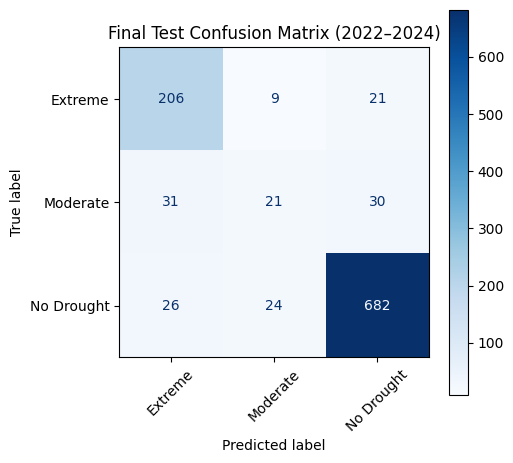

In [27]:
#Apply SMOTE to full training set (2015–2021)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_1m_train)

# Train RF on resampled set
model_rf_smote = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'
)
model_rf_smote.fit(X_train_resampled, y_train_resampled)

# Predict on hold-out test (2022–2024)
y_1m_pred_rf_smote = model_rf_smote.predict(X_test)

print("\n Final Test Classification Report:")
print(classification_report(y_1m_test, y_1m_pred_rf_smote))

# Confusion Matrix for test set
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_1m_test, y_1m_pred_rf_smote,
    cmap="Blues",
    xticks_rotation=45,
    ax=ax
)
plt.title("Final Test Confusion Matrix (2022–2024)")
plt.show()


CV without SMOTE

In [28]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

fold = 1
cv_scores = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_1m_train.iloc[train_idx], y_1m_train.iloc[val_idx]

#model training
    model_rf = RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    )
    model_rf.fit(X_tr, y_tr)

    # Predict
    y_val_pred = model_rf.predict(X_val)

    # Evaluate
    acc = accuracy_score(y_val, y_val_pred)
    cv_scores.append(acc)

    print(f"\nFold {fold} Accuracy: {acc:.4f}")
    print(classification_report(y_val, y_val_pred))

    fold += 1

print("\n✅ Mean CV Accuracy across folds:", np.mean(cv_scores))



Fold 1 Accuracy: 0.8630
              precision    recall  f1-score   support

     Extreme       0.89      0.86      0.88       118
    Moderate       0.64      0.41      0.50        61
  No Drought       0.88      0.96      0.92       281

    accuracy                           0.86       460
   macro avg       0.81      0.75      0.77       460
weighted avg       0.85      0.86      0.85       460


Fold 2 Accuracy: 0.8739
              precision    recall  f1-score   support

     Extreme       0.86      0.86      0.86       177
    Moderate       0.15      0.11      0.13        27
  No Drought       0.94      0.96      0.95       256

    accuracy                           0.87       460
   macro avg       0.65      0.64      0.65       460
weighted avg       0.86      0.87      0.87       460


Fold 3 Accuracy: 0.8739
              precision    recall  f1-score   support

     Extreme       0.83      0.91      0.87       150
    Moderate       0.65      0.23      0.34        47


CV with SMOTE

In [29]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)
smote = SMOTE(random_state=42)

cv_scores = []
fold = 1

for train_idx, val_idx in tscv.split(X_train):
    # Split by indices
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_1m_train.iloc[train_idx], y_1m_train.iloc[val_idx]

    # SMOTE only on training fold
    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

    model_rf_smote = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight='balanced'
    )
    model_rf_smote.fit(X_tr_res, y_tr_res)

    # Predict validation
    y_val_pred = model_rf_smote.predict(X_val)

    # Metrics
    acc = accuracy_score(y_val, y_val_pred)
    cv_scores.append(acc)

    print(f"\n Fold {fold} Accuracy: {acc:.4f}")
    print(classification_report(y_val, y_val_pred))

    fold += 1

''' # Confusion Matrix
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_val_pred,
        cmap="Blues",
        xticks_rotation=45,
        ax=ax
    )
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.show()
'''

print("\nMean CV Accuracy with SMOTE:", np.mean(cv_scores))



 Fold 1 Accuracy: 0.8478
              precision    recall  f1-score   support

     Extreme       0.91      0.79      0.85       118
    Moderate       0.52      0.72      0.60        61
  No Drought       0.93      0.90      0.91       281

    accuracy                           0.85       460
   macro avg       0.79      0.80      0.79       460
weighted avg       0.87      0.85      0.85       460


 Fold 2 Accuracy: 0.8326
              precision    recall  f1-score   support

     Extreme       0.83      0.81      0.82       177
    Moderate       0.16      0.26      0.19        27
  No Drought       0.96      0.91      0.93       256

    accuracy                           0.83       460
   macro avg       0.65      0.66      0.65       460
weighted avg       0.86      0.83      0.85       460


 Fold 3 Accuracy: 0.8804
              precision    recall  f1-score   support

     Extreme       0.86      0.92      0.89       150
    Moderate       0.50      0.40      0.45        

Hyperparameter Tuning

In [30]:
param_grid = {
    'n_estimators': [200, 500, 800],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [32]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Example: Define model
model_rf = RandomForestClassifier(random_state=42)

# Define parameter distribution (use distributions for continuous/randomized search)
param_dist = {
    'n_estimators': randint(100, 500),    # Random integers between 100 and 500
    'max_depth': randint(5, 30),          # Random integers between 5 and 30
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]  # Random choice from list
}

# Time series split
tscv = TimeSeriesSplit(n_splits=5)

# RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model_rf,
    param_distributions=param_dist,
    n_iter=50,                 # Number of random combinations to try
    cv=tscv,
    scoring='f1_macro',        # Suitable for imbalanced classes
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit on training data
random_search.fit(X_train, y_1m_train)

# Print results
print("Best Params:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 158}
Best CV Score: 0.7048272332750518


In [33]:
best_rf = random_search.best_estimator_

In [34]:
print("LabelEncoder classes:", le.classes_)
print("Unique in y_train:", np.unique(y_1m_train))


LabelEncoder classes: ['Ahmednagar' 'Akola' 'Amravati' 'Aurangabad' 'Bhandara' 'Bid' 'Buldana'
 'Chandrapur' 'Dhule' 'Garhchiroli' 'Gondiya' 'Hingoli' 'Jalgaon' 'Jalna'
 'Kolhapur' 'Latur' 'Mumbai City' 'Mumbai Suburban' 'Nagpur' 'Nanded'
 'Nandurbar' 'Nashik' 'Osmanabad' 'Parbhani' 'Pune' 'Raigarh' 'Ratnagiri'
 'Sangli' 'Satara' 'Sindhudurg' 'Solapur' 'Thane' 'Wardha' 'Washim'
 'Yavatmal']
Unique in y_train: ['Extreme' 'Moderate' 'No Drought']


=== Tuned RF Results (Test Set) ===
              precision    recall  f1-score   support

     Extreme       0.78      0.88      0.83       236
    Moderate       0.46      0.16      0.24        82
  No Drought       0.92      0.95      0.93       732

    accuracy                           0.87      1050
   macro avg       0.72      0.66      0.66      1050
weighted avg       0.85      0.87      0.85      1050

Macro F1 (Test): 0.6647114764086104


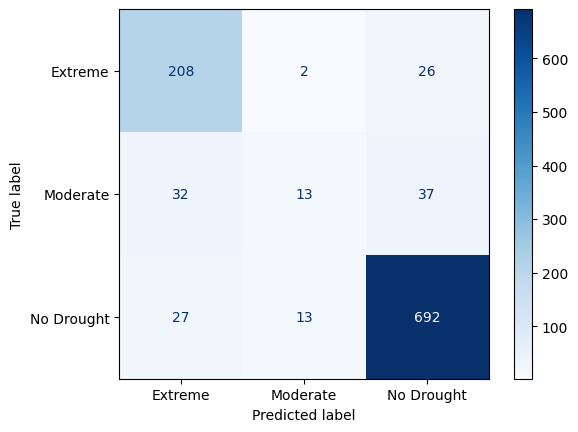

In [35]:
#training model with best param
best_rf = random_search.best_estimator_

y_rf_test_pred = best_rf.predict(X_test)

from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("=== Tuned RF Results (Test Set) ===")
print(classification_report(y_1m_test, y_rf_test_pred))   # no encoding needed

rf_tuned_f1 = f1_score(y_1m_test, y_rf_test_pred, average="macro")
print("Macro F1 (Test):", rf_tuned_f1)

ConfusionMatrixDisplay.from_predictions(
    y_1m_test, y_rf_test_pred,
    cmap="Blues"
)
plt.show()


Comparison

In [36]:
from sklearn.metrics import classification_report

print("=== Baseline Random Forest ===")
print(classification_report(y_1m_test, y_1m_pred_rf))

print("=== Random Forest with SMOTE ===")
print(classification_report(y_1m_test, y_1m_pred_rf_smote))

print("\n=== Tuned Random Forest ===")
print(classification_report(y_1m_test, y_rf_test_pred))

# Calculate improvement
improvement = rf_tuned_f1 - rf_f1
print(f"\nF1 Score Improvement: {improvement:.4f} ({improvement*100:.2f}%)")

=== Baseline Random Forest ===
              precision    recall  f1-score   support

     Extreme       0.76      0.88      0.81       236
    Moderate       0.39      0.11      0.17        82
  No Drought       0.92      0.94      0.93       732

    accuracy                           0.86      1050
   macro avg       0.69      0.64      0.64      1050
weighted avg       0.84      0.86      0.84      1050

=== Random Forest with SMOTE ===
              precision    recall  f1-score   support

     Extreme       0.78      0.87      0.83       236
    Moderate       0.39      0.26      0.31        82
  No Drought       0.93      0.93      0.93       732

    accuracy                           0.87      1050
   macro avg       0.70      0.69      0.69      1050
weighted avg       0.86      0.87      0.86      1050


=== Tuned Random Forest ===
              precision    recall  f1-score   support

     Extreme       0.78      0.88      0.83       236
    Moderate       0.46      0.16   

In [38]:
# RandomizedSearchCV
random_search_smote = RandomizedSearchCV(
    estimator=model_rf_smote,
    param_distributions=param_dist,
    n_iter=50,                 # Number of random combinations to try
    cv=tscv,
    scoring='f1_macro',        # Suitable for imbalanced classes
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit on training data
random_search_smote.fit(X_train_resampled, y_train_resampled)

# Print results
print("Best Params:", random_search_smote.best_params_)
print("Best CV Score:", random_search_smote.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'max_depth': 28, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 9, 'n_estimators': 162}
Best CV Score: 0.5977908990225448


=== Tuned RF Results (Test Set) ===
              precision    recall  f1-score   support

     Extreme       0.78      0.85      0.81       236
    Moderate       0.34      0.24      0.29        82
  No Drought       0.93      0.93      0.93       732

    accuracy                           0.86      1050
   macro avg       0.68      0.68      0.68      1050
weighted avg       0.85      0.86      0.85      1050

Macro F1 (Test): 0.6762978394377712


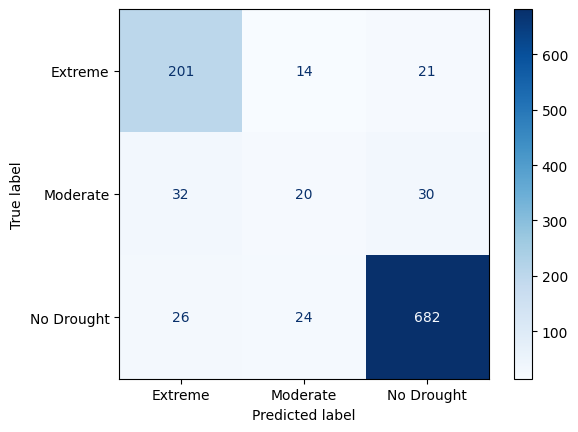

In [39]:
#training model with best param
best_rf_smote = random_search_smote.best_estimator_

y_rf_test_pred_smote = best_rf_smote.predict(X_test)

from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("=== Tuned RF Results (Test Set) ===")
print(classification_report(y_1m_test, y_rf_test_pred_smote))   # no encoding needed

rf_tuned_f1_smote = f1_score(y_1m_test, y_rf_test_pred_smote, average="macro")
print("Macro F1 (Test):", rf_tuned_f1_smote)

ConfusionMatrixDisplay.from_predictions(
    y_1m_test, y_rf_test_pred_smote,
    cmap="Blues"
)
plt.show()


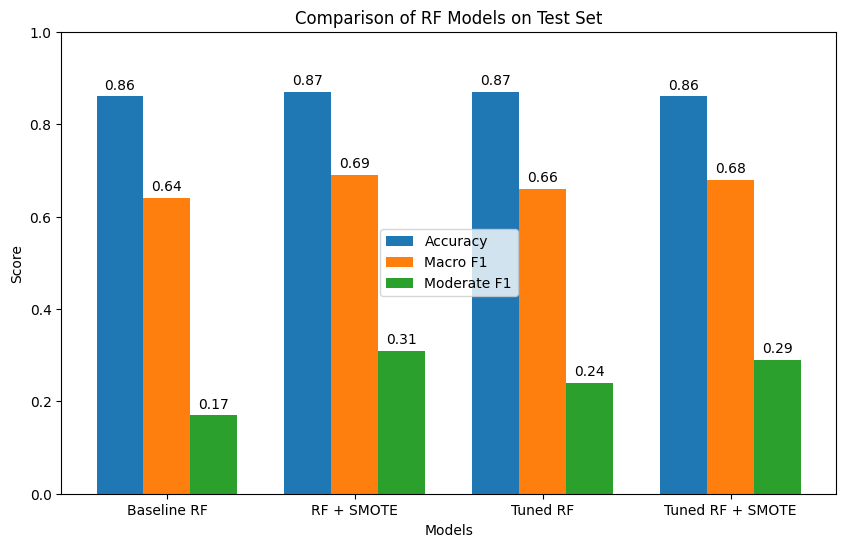

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Baseline RF', 'RF + SMOTE', 'Tuned RF', 'Tuned RF + SMOTE']

# Metrics (replace these with your actual numbers)
accuracy = [0.86, 0.87, 0.87, 0.86]      # Accuracy
macro_f1 = [0.64, 0.69, 0.66, 0.68]      # Macro F1
moderate_f1 = [0.17, 0.31, 0.24, 0.29]   # Moderate class F1

# Set position of bar on X axis
x = np.arange(len(models))
width = 0.25

# Plot bars
fig, ax = plt.subplots(figsize=(10,6))
bar1 = ax.bar(x - width, accuracy, width, label='Accuracy', color='#1f77b4')
bar2 = ax.bar(x, macro_f1, width, label='Macro F1', color='#ff7f0e')
bar3 = ax.bar(x + width, moderate_f1, width, label='Moderate F1', color='#2ca02c')

# Add labels and title
ax.set_ylabel('Score')
ax.set_xlabel('Models')
ax.set_title('Comparison of RF Models on Test Set')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0,1)
ax.legend()

# Add value labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords='offset points',
                    ha='center', va='bottom')

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

plt.show()
